In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
import shap
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Меняем на Light Mode (светлая тема с аккуратной сеткой)
plt.style.use('default')
sns.set_theme(style="whitegrid")
shap.initjs()

In [ ]:
# Загружаем данные со сделками (до того, как к ним применили Тройной Барьер)
df = pd.read_csv("../data/processed/strategy_labeled_data.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

print(f"Total rows loaded: {len(df)}")
print(f"Setups generated by strategy: {df['active_setup'].notna().sum()}")

# Список наших фичей (включая новые текстовые)
features_list = [
    'active_setup', 'volatility_z', 'changepoint_prob', 'trend_strength', 
    'cusum_signal', 'asia_intensity', 'london_intensity', 'ny_intensity', 
    'session_overlap_score', 'dist_to_pwh', 'dist_to_pwl', 'mtfa_score', 
    "llm_sentiment_score", "is_macro_alignment", "active_session_name",
    "dist_to_pdh", "dist_to_pdl","linreg_score", "hour_sin", "hour_cos","day_sin", "day_cos"
]

Total rows loaded: 624213
Setups generated by strategy: 35356


In [36]:
def generate_labels_fast(df, target_rr=2.0, horizon_bars=480):
    labeled_df = df.copy()
    labeled_df['active_setup'] = labeled_df['active_setup'].astype(str)
    mask = (labeled_df['active_setup'] != 'None') & (labeled_df['active_setup'] != 'nan')
    
    signal_locs = np.where(mask)[0]
    close_arr = labeled_df['close'].values
    high_arr = labeled_df['high'].values
    low_arr = labeled_df['low'].values
    atr_arr = labeled_df['atr_pct'].values
    dayofweek_arr = labeled_df.index.dayofweek.values
    hour_arr = labeled_df.index.hour.values
    
    direction_arr = labeled_df['signal'].values
    meta_labels = np.full(len(labeled_df), np.nan)
    target_rr_arr = np.where(dayofweek_arr == 3, 3.0, target_rr) # Четверг = 1:3
    
    for loc in signal_locs:
        if loc + 1 >= len(labeled_df): continue
        entry_price = close_arr[loc]
        direction = direction_arr[loc]
        if direction == 0 or pd.isna(direction): continue
            
        stop_dist = entry_price * atr_arr[loc]
        take_dist = stop_dist * target_rr_arr[loc]
        
        stop_price = entry_price - (direction * stop_dist)
        take_price = entry_price + (direction * take_dist)
        
        end_loc = min(loc + horizon_bars + 1, len(labeled_df))
        f_highs, f_lows = high_arr[loc+1:end_loc], low_arr[loc+1:end_loc]
        f_dow, f_hour = dayofweek_arr[loc+1:end_loc], hour_arr[loc+1:end_loc]
        
        if direction == 1:
            stops = np.where(f_lows <= stop_price)[0]
            takes = np.where(f_highs >= take_price)[0]
        else:
            stops = np.where(f_highs >= stop_price)[0]
            takes = np.where(f_lows <= take_price)[0]
            
        fridays = np.where((f_dow == 4) & (f_hour >= 21))[0]
        
        stop_idx = stops[0] if len(stops) > 0 else 9999
        take_idx = takes[0] if len(takes) > 0 else 9999
        time_idx = fridays[0] if len(fridays) > 0 else 9999
        
        first_event = min(take_idx, stop_idx, time_idx)
        if first_event == take_idx: meta_labels[loc] = 1
        else: meta_labels[loc] = 0
            
    labeled_df['meta_label'] = meta_labels
    return labeled_df.dropna(subset=['meta_label'])

train_ready_df = generate_labels_fast(df)
print(f"Total valid setups for ML: {len(train_ready_df)}")
print(f"Baseline Win Rate: {train_ready_df['meta_label'].mean():.2%}")

Total valid setups for ML: 35356
Baseline Win Rate: 31.91%


In [37]:
# Заполняем пустоты в тексте (критично для CatBoost)
train_ready_df['active_setup'] = train_ready_df['active_setup'].fillna("None").astype(str)
train_ready_df['active_session_name'] = train_ready_df['active_session_name'].fillna("Asian").astype(str)

X = train_ready_df[features_list]
y = train_ready_df['meta_label'].astype(int)

# Временной сплит (не перемешиваем!)
split_idx = int(len(train_ready_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

cat_features = ['active_setup', 'active_session_name']

train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool = Pool(X_test, y_test, cat_features=cat_features)

model = CatBoostClassifier(
    iterations=500, learning_rate=0.03, depth=5, 
    eval_metric='Logloss', random_seed=42, early_stopping_rounds=50, verbose=False
)
model.fit(train_pool, eval_set=test_pool)
print("Model trained!")

Model trained!


Classification Report:
              precision    recall  f1-score   support

           0       0.66      1.00      0.79      4656
           1       0.00      0.00      0.00      2416

    accuracy                           0.66      7072
   macro avg       0.33      0.50      0.40      7072
weighted avg       0.43      0.66      0.52      7072

ROC-AUC Score: 0.5111


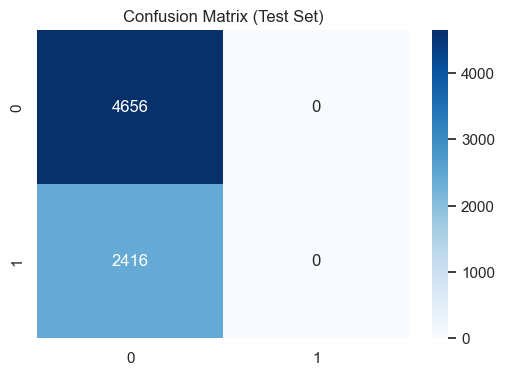

In [38]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("Classification Report:")
# Добавлен параметр zero_division=0 для защиты от деления на ноль
print(classification_report(y_test, y_pred, zero_division=0))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Test Set)")
plt.show()

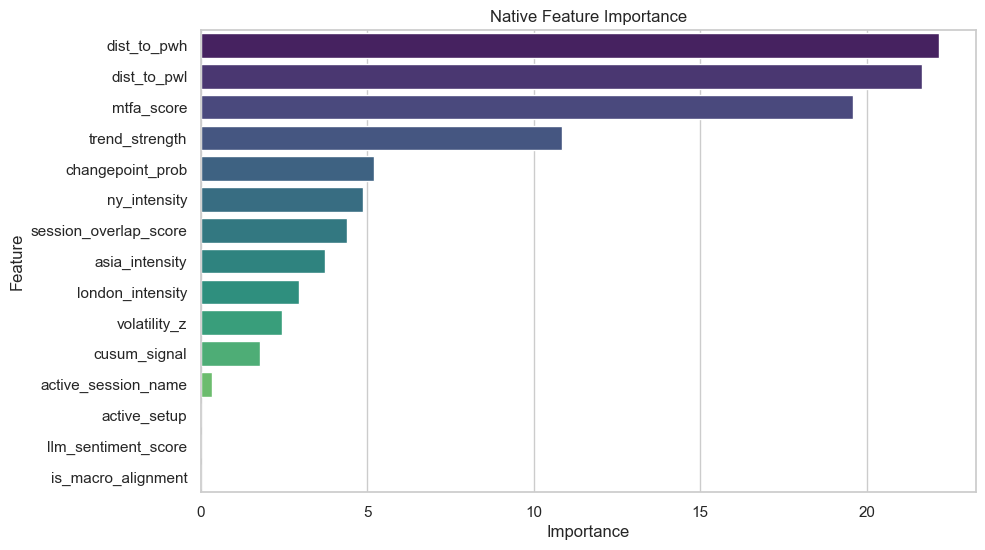

In [39]:
feature_importances = model.get_feature_importance(train_pool)
importance_df = pd.DataFrame({'Feature': features_list, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
# Добавлены параметры hue='Feature' и legend=False, чтобы убрать предупреждение
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df, 
    palette='viridis',
    hue='Feature',
    legend=False
)
plt.title('Native Feature Importance')
plt.show()

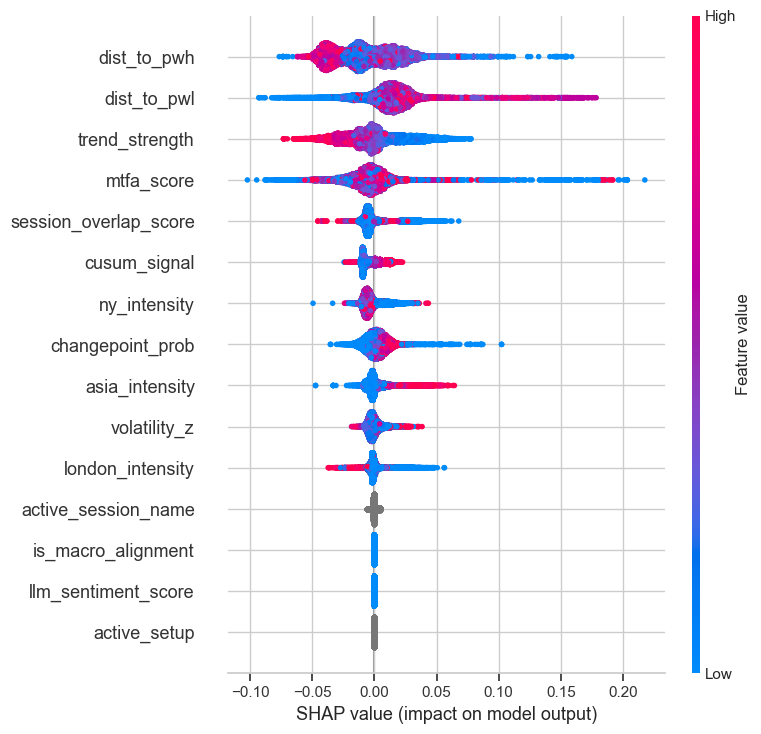

In [40]:
# SHAP Explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(train_pool)

# Выводим SHAP Summary Plot
shap.summary_plot(shap_values, X_train, feature_names=features_list)